<a href="https://colab.research.google.com/github/zamman365-glitch/Machine-Learning-/blob/main/Linear_Ridge_%26_Lasso_Regression_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Car Price Prediction — Linear, Ridge & Lasso Regression

**Dataset:** Used Car Sales Data  
**Goal:** Predict the price of a used car based on its features  
**Models Used:** Linear Regression → Ridge → Lasso

---

> 💡 **What will you learn?**
> - How to clean a real-world messy dataset
> - Why we use log transformation on skewed data
> - How Linear, Ridge, and Lasso Regression work
> - How to compare models and pick the best one

## Step 1 — Import Libraries

**Why?**  
Before doing anything, we load the tools we need.
- `pandas` → to load and work with data (like Excel in Python)
- `numpy` → for math operations
- `matplotlib` & `seaborn` → to make graphs
- `sklearn` → machine learning models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load the Dataset

**Why?**  
We load our CSV file into a DataFrame — think of it as opening an Excel sheet in Python.

After loading, we always check:
- How many rows and columns are there?
- What does the data look like?

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "1.04. Real-life example.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "smritisingh1997/car-salescsv",
  file_path,

)

print("First 5 records:", df.head())

/tmp/ipykernel_1911/167104996.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'car-salescsv' dataset.
First 5 records:            Brand    Price       Body  Mileage  EngineV Engine Type  \
0            BMW   4200.0      sedan      277      2.0      Petrol   
1  Mercedes-Benz   7900.0        van      427      2.9      Diesel   
2  Mercedes-Benz  13300.0      sedan      358      5.0         Gas   
3           Audi  23000.0  crossover      240      4.2      Petrol   
4         Toyota  18300.0  crossover      120      2.0      Petrol   

  Registration  Year         Model  
0          yes  1991           320  
1          yes  1999  Sprinter 212  
2          yes  2003         S 500  
3          yes  2007            Q7  
4          yes  2011         Rav 4  


## Step 3 — Explore the Data (EDA)

**Why?**  
Before building any model, we need to *understand* our data.

We check:
- Data types of each column
- Basic statistics (min, max, average)
- Missing values — are there any empty cells?

> ⚠️ **Real-world data is almost never clean. Always explore first!**

In [ ]:
df.dtypes
df.describe()
df.isnull().sum()


,0
Brand,0
Price,172
Body,0
Mileage,0
EngineV,150
Engine Type,0
Registration,0
Year,0
Model,0


## Step 4 — Handle Missing Values

**Why?**  
Machine learning models cannot work with empty (NaN) values.  
We have missing values in `Price` and `EngineV`.

**Solution:** Drop rows where Price or EngineV is missing.

> 💡 `dropna()` removes rows that have missing values in the specified columns.

In [ ]:
df = df.dropna(subset =['Price', 'EngineV'])
df.isnull().sum()


,0
Brand,0
Price,0
Body,0
Mileage,0
EngineV,0
Engine Type,0
Registration,0
Year,0
Model,0


## Step 5 — Remove Outliers from EngineV

**Why?**  
Look at the max value of `EngineV` — it shows **99.99!**  
No car has a 99-litre engine. These are data entry mistakes.

Outliers confuse the model and give wrong predictions.  
We keep only realistic engine sizes (≤ 10 litres).

> 💡 Always ask: *"Does this value make real-world sense?"*

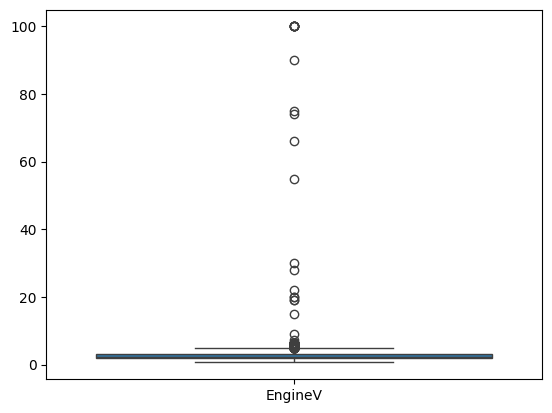

In [ ]:
num_col=['EngineV']
sns.boxplot(data=df[num_col])
df = df[df['EngineV'] <= 10]


## Step 6 — Check Distribution of Target Variable (Price)

**Why?**  
Linear Regression works best when the target variable is **normally distributed** (bell-shaped).  

Let's plot `Price` and see its shape.

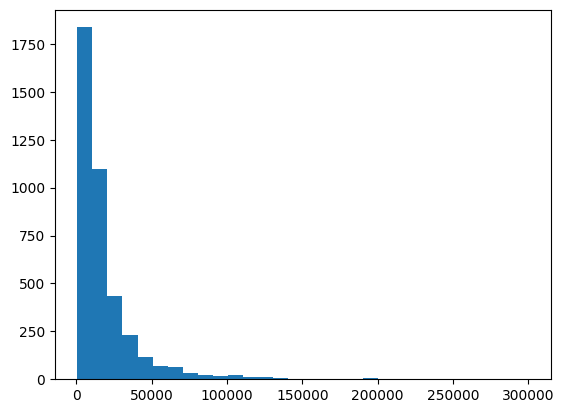

In [ ]:
plt.hist(df['Price'], bins=30)
plt.show()

## Step 7 — Apply Log Transformation

**Why?**  
The raw `Price` is heavily right-skewed (skewness = 4.45).  
After `log(Price)`, skewness drops to ~0.24 — almost normal!

This helps our model make much better predictions.

> ⚠️ We also drop the `Model` column — it has 312 unique values (too many for simple encoding).

(array([  2.,   0.,   1.,   0.,   2.,   7.,  11.,  19.,  17.,  33.,  53.,
         75.,  70.,  63.,  85.,  91.,  92., 104., 113., 218., 217., 290.,
        235., 259., 260., 199., 156., 184., 170., 147., 105., 131., 100.,
         99.,  64.,  65.,  40.,  46.,  49.,  23.,  14.,  34.,  19.,  13.,
          4.,   6.,  11.,   3.,   2.,   4.]),
 array([ 6.39692966,  6.52122182,  6.64551398,  6.76980614,  6.8940983 ,
         7.01839047,  7.14268263,  7.26697479,  7.39126695,  7.51555911,
         7.63985127,  7.76414344,  7.8884356 ,  8.01272776,  8.13701992,
         8.26131208,  8.38560425,  8.50989641,  8.63418857,  8.75848073,
         8.88277289,  9.00706506,  9.13135722,  9.25564938,  9.37994154,
         9.5042337 ,  9.62852587,  9.75281803,  9.87711019, 10.00140235,
        10.12569451, 10.24998668, 10.37427884, 10.498571  , 10.62286316,
        10.74715532, 10.87144749, 10.99573965, 11.12003181, 11.24432397,
        11.36861613, 11.4929083 , 11.61720046, 11.74149262, 11.86578478,
 

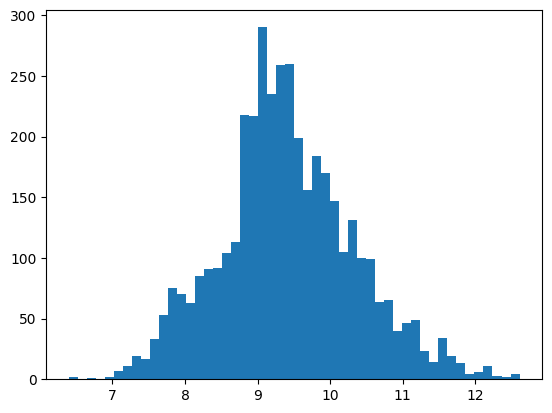

In [ ]:
df['Log_price']=np.log(df['Price'])

plt.hist(df['Log_price'], bins=50)

In [ ]:
df['Model'].nunique()


305

## Step 8 — Encode Categorical Columns

**Why?**  
Machine learning models only understand **numbers**, not text like 'BMW' or 'Diesel'.

We use **Label Encoding** to convert text categories into numbers.

| Text | Encoded |
|------|---------|
| Audi | 0 |
| BMW  | 1 |
| Toyota | 2 |

> 💡 `LabelEncoder` assigns a unique number to each category automatically.

In [ ]:
df
# encoding :-text column ko vector mei convert karte hai
# 2 type of encoding
# 1:- label encoding :- categorical text values into numerical values so algorithms can process them.Normally, value assign kar dete hai
# 2:- one hat encoding :-

#      Red ,green, blue
# Red → [1, 0, 0]

# Green → [0, 1, 0]

# Blue → [0, 0, 1]




,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,Log_price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4,9.814656
...,...,...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,Corolla,9.792556
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350,11.736069
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535,8.779557
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520,8.987197


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_col=df.select_dtypes(include=['object']).columns
for col in cat_col:
    df[col]=le.fit_transform(df[col])
df


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,Log_price
0,1,4200.0,3,277,2.0,3,1,1991,18,8.342840
1,2,7900.0,5,427,2.9,0,1,1999,260,8.974618
2,2,13300.0,3,358,5.0,1,1,2003,232,9.495519
3,0,23000.0,0,240,4.2,3,1,2007,219,10.043249
4,5,18300.0,0,120,2.0,3,1,2011,222,9.814656
...,...,...,...,...,...,...,...,...,...,...
4339,5,17900.0,3,35,1.6,3,1,2014,110,9.792556
4340,2,125000.0,3,9,3.0,0,1,2014,228,11.736069
4341,1,6500.0,3,1,3.5,3,1,1999,37,8.779557
4342,1,8000.0,3,194,2.0,3,1,1985,31,8.987197


## Step 9 — Correlation Heatmap

**Why?**  
A heatmap shows how strongly each feature is related to `log_price`.

- Value close to **+1** → strong positive relationship (feature goes up, price goes up)
- Value close to **-1** → strong negative relationship (feature goes up, price goes down)
- Value close to **0** → weak/no relationship

> 💡 This helps us understand which features are most important for prediction.

<Axes: >

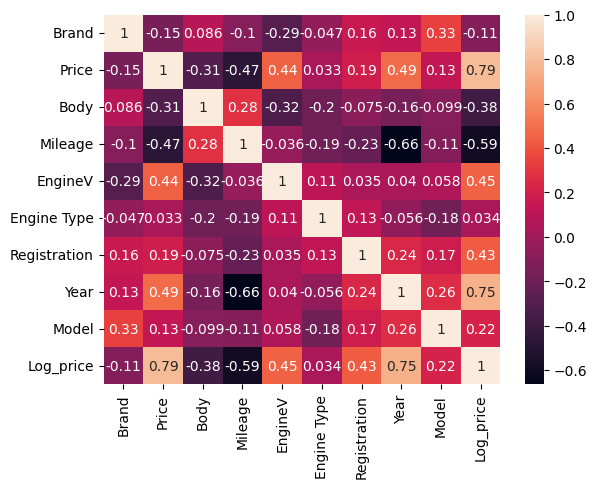

In [ ]:
sns.heatmap(df.corr(), annot=True)

## Step 10 — Split Data into Train and Test Sets

**Why?**  
We train the model on one part of the data, and test it on a *different* part it has never seen.

This tells us how well the model performs on **new, unseen data** — which is the real goal!

| Split | Purpose |
|-------|---------|
| 80% Train | Model learns from this |
| 20% Test  | We evaluate model here |

> 💡 `random_state=42` ensures same split every time you run the code.

In [ ]:
X=df.drop(['Price','Log_price'],axis=1)
y=df['Log_price']
X
y

,Log_price
0,8.342840
1,8.974618
2,9.495519
3,10.043249
4,9.814656
...,...
4339,9.792556
4340,11.736069
4341,8.779557
4342,8.987197


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (3204, 8)
X_test shape: (801, 8)
y_train shape: (3204,)
y_test shape: (801,)


## Step 11 — Linear Regression

**Why start here?**  
Linear Regression is the simplest and most foundational regression model.

It finds the best straight line (or plane in multiple dimensions) that fits the data.

**Formula:**  
`Price = b0 + b1×Year + b2×Mileage + b3×EngineV + ...`

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression() # linear regression class
reg.fit(X_train, y_train) # object  , fit:- fit mtlb measure





LinearRegression()

In [ ]:

y_predicat=reg.predict(np.array(X_test))
y_predicat[ : 10]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 9.10311818,  9.50025866,  9.41793917,  7.58296034,  9.51423061,
       10.26781447,  8.95737889,  9.53411402,  8.92694206,  7.40976862])

In [ ]:
compare=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_predicat
})
compare.head(10)

,Actual,Predicted
822,9.071078,9.103118
1132,8.764053,9.500259
1717,9.711116,9.417939
3781,8.612503,7.582960
3432,8.809863,9.514231
2279,10.232791,10.267814
1612,8.974618,8.957379
897,9.775370,9.534114
2183,8.839277,8.926942
4216,8.039157,7.409769


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, y_predicat)
# preformance batata hai r2


0.8298264099466404

## Step 12 — Ridge Regression

**Why Ridge?**  
Ridge is Linear Regression with a **penalty** added.

When we have many features, some coefficients can get very large — this causes **overfitting** (model memorizes training data but fails on new data).

Ridge **shrinks** large coefficients without removing any feature completely.

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
clf = Ridge()
clf.fit(X_train, y_train)
y_predicat=clf.predict(np.array(X_test))
y_predicat[ : 10]

Ridge()

## Step 13 — Lasso Regression

**Why Lasso?**  
Lasso is similar to Ridge but with one key difference:

Lasso can make some feature coefficients exactly **zero** — meaning it **removes** unimportant features automatically!

This is called **automatic feature selection** — very useful when you have many features and don't know which ones matter.

In [ ]:
##fhiii

## Step 14 — Compare All Three Models

**Why compare?**  
No single model is always the best. We compare R² and RMSE to choose the winner.

- **Higher R²** = Better (closer to 1.0 is ideal)
- **Lower RMSE** = Better (smaller error is better)

## Step 15 — Actual vs Predicted Plot

**Why?**  
Numbers alone don't tell the full story. This plot shows visually how close our predictions are to the actual prices.

- If points lie **on the red diagonal line** → perfect predictions
- Points **scattered away** from the line → prediction errors
